# Chapter 1: The Fundamental Group

**Source Span.** `Algebraic Topology.pdf`, printed pages `21-96` (physical PDF pages `30-105` in this copy).
**Chapter goal.** Turn loops, homotopies, presentations, and covering spaces into inspectable finite models: paths become arrays, products become word operations, van Kampen becomes a quotient recipe, and coverings become permutations on fibers.

The fundamental group is the first algebraic invariant in the course that remembers how paths can fail to contract. This notebook is standalone: it uses the source span for terminology and chapter organization, but the explanations, examples, computations, and visual artifacts below are original. The guiding question is:

> When does a visible path operation or covering-space symmetry become a group-theoretic operation, relation, or quotient?

The notebook uses small finite witnesses. They do not replace the theorems, but they expose what the theorems are tracking: endpoints, basepoints, lifted endpoints, normal closures, reduced words, deck transformations, and tree-like universal covers.

## Computational Translation Guide

| Source idea | Computational proxy | What to inspect |
| --- | --- | --- |
| Endpoint-fixed path homotopy | arrays `F(s,t)` with first and last samples fixed | endpoints do not move while the middle of the path does |
| Loop product and inverse | piecewise parameterized curves and reduced words | product order matters before abelianization |
| Change of basepoint | conjugation `h alpha h^{-1}` | basepoint moves alter representatives by conjugacy |
| `pi_1(S^1) = Z` | lift of an angle path to the real line | lifted endpoint is the winding number |
| Induced homomorphism | commutative diagram plus degree multiplication | maps of spaces become maps of groups |
| van Kampen | cover nerve and normal closure of overlap relations | local groups assemble, then overlap loops are identified |
| 2-cell presentations | relator vectors and abelianization ranks/torsion | attaching maps kill normal subgroups |
| Covering classification | monodromy permutations on a finite fiber | connected components are orbits; normal covers are regular actions |
| Graphs and free groups | spanning tree plus chord basis | rank is `E - V + 1` for a connected finite graph |
| `K(G,1)` and Bass-Serre | finite truncation of an action tree | higher homotopy is suppressed; group splitting appears as a tree |

### Chapter-Specific Library Routing

| Library | Used for | Why it fits this chapter |
| --- | --- | --- |
| NumPy | path samples, winding, parameterized curves | loops and lifts are naturally sampled functions |
| Plotly | path/lift widgets and torus-knot inspection | interactive HTML lets learners rotate or compare geometry without changing code |
| NetworkX | cover graphs, nerves, spanning trees, Bass-Serre truncations | fundamental group computations often reduce to graph structure |
| Matplotlib | durable proof diagrams and annotated finite models | clear static PNG artifacts work well for theorem scaffolds |
| SymPy | abelianization and small exact integer checks | presentations and relators are exact algebra, not floating-point geometry |

The generated paths are book-local through `utils.artifacts.chapter_artifact_root`. Plotly artifacts are saved as standalone HTML; proof and graph diagrams are saved as PNG; invariant summaries are saved as JSON/CSV.

## Visual Storyboard

1. `path-homotopy-and-product`: endpoint-fixed homotopy and loop concatenation as sampled curves.
2. `basepoint-change-conjugation`: how changing basepoints conjugates loop classes.
3. `circle-lift-winding`: `S^1` loops classified by lifted endpoint displacement.
4. `induced-homomorphism-diagrams`: functoriality, products, and retractions in one proof diagram.
5. `free-product-word-reduction`: reduced words as a visible cancellation process.
6. `van-kampen-cover-nerve`: cover hypotheses and overlap relations as a quotient diagram.
7. `two-cell-surface-presentations`: surface relators and abelianization checks.
8. `torus-knot-presentation`: a torus knot plus the relator `a^m=b^n`.
9. `covering-space-gallery`: finite covers encoded by labeled graph edges.
10. `monodromy-permutations`: lifting loops as permutations of a fiber.
11. `covering-classification-lattice`: covering partial order versus subgroup inclusion.
12. `deck-normality-quotient`: normality as regular fiber symmetry and quotient deck group.
13. `graph-maximal-tree-free-basis`: free basis from edges outside a maximal tree.
14. `bass-serre-tree-expansion`: finite truncation of a graph-of-groups universal tree.

In [1]:
from __future__ import annotations

from itertools import permutations
from math import gcd, pi
from pathlib import Path
import json
import sys

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "source_map.json").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
    course = candidate / "Algebraic-Topology"
    if (course / "AGENTS.md").exists() and (course / "source_map.json").exists() and (course / "utils").exists():
        BOOK_ROOT = course
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not locate Algebraic-Topology course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

UNIT_KEY = "chapter-01-the-fundamental-group"
UNIT_TITLE = "The Fundamental Group"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.labelcolor": "#222222",
    "text.color": "#222222",
    "font.size": 10,
})

artifact_paths: list[Path] = []
check_paths: list[Path] = []
check_data: dict[str, object] = {}

routing_rows = [
    {"concept": "endpoint-fixed homotopy", "library": "Plotly + NumPy", "artifact": "html/path-homotopy-and-product.html", "check": "endpoints remain fixed"},
    {"concept": "basepoint change", "library": "NetworkX + Matplotlib", "artifact": "figures/basepoint-change-conjugation.png", "check": "conjugation is a homomorphism"},
    {"concept": "circle winding", "library": "Plotly + NumPy", "artifact": "html/circle-lift-winding.html", "check": "lift endpoint equals winding number"},
    {"concept": "van Kampen", "library": "NetworkX + SymPy", "artifact": "figures/van-kampen-cover-nerve.png", "check": "overlap relators enter a normal quotient"},
    {"concept": "covering monodromy", "library": "NetworkX + permutations", "artifact": "figures/monodromy-permutations.png", "check": "orbits and deck centralizers agree"},
]
routing_path = save_csv(routing_rows, TABLES / "chapter-01-library-routing.csv")
artifact_paths.append(routing_path)

print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {ARTIFACT_ROOT.relative_to(BOOK_ROOT)}")

Book root: D:\Geometry\Algebraic-Topology
Artifact root: artifacts\chapter-01-the-fundamental-group


## 1. Paths, Homotopy, and Loop Product

A path homotopy is stricter than a vague deformation: its endpoints are pinned for every time value. The first artifact samples two paths with the same endpoints and linearly interpolates between them. The right panel then shows a loop product: traverse one loop, then traverse the next, with the basepoint appearing at the join.

The inspection target is simple: if the endpoints drift, the model is not a homotopy of paths with fixed endpoints. If the join point is not the basepoint, the loop product is not even defined in `pi_1(X,x_0)`.

In [2]:
s = np.linspace(0, 1, 160)
path_start = np.array([0.0, 0.0])
path_end = np.array([1.0, 0.0])

def f0(s):
    return np.column_stack([s, 0.22 * np.sin(pi * s)])

def f1(s):
    return np.column_stack([s, -0.34 * np.sin(pi * s) + 0.08 * np.sin(2 * pi * s)])

homotopy_traces = []
for t in [0.0, 0.25, 0.5, 0.75, 1.0]:
    pts = (1 - t) * f0(s) + t * f1(s)
    homotopy_traces.append(go.Scatter(x=pts[:, 0], y=pts[:, 1], mode="lines", name=f"t={t:.2f}"))

u = np.linspace(0, 1, 120)
loop_a = np.column_stack([0.25 * np.cos(2*pi*u), 0.25 * np.sin(2*pi*u)])
loop_b = np.column_stack([0.44 + 0.18 * np.cos(2*pi*u), 0.18 * np.sin(2*pi*u)])
product_basepoint = loop_a[0]
connector = np.column_stack([np.linspace(loop_a[-1,0], loop_b[0,0], 20), np.linspace(loop_a[-1,1], loop_b[0,1], 20)])
product_curve = np.vstack([loop_a, connector, loop_b, connector[::-1]])

fig = make_subplots(rows=1, cols=2, subplot_titles=("Endpoint-fixed homotopy", "Loop product at one basepoint"))
for trace in homotopy_traces:
    fig.add_trace(trace, row=1, col=1)
fig.add_trace(go.Scatter(x=[path_start[0], path_end[0]], y=[path_start[1], path_end[1]], mode="markers+text", text=["x0", "x1"], textposition="bottom center", marker=dict(size=10, color="#222222"), name="fixed endpoints"), row=1, col=1)
fig.add_trace(go.Scatter(x=product_curve[:,0], y=product_curve[:,1], mode="lines", line=dict(width=4, color="#3b6ea8"), name="alpha beta"), row=1, col=2)
fig.add_trace(go.Scatter(x=[product_basepoint[0]], y=[product_basepoint[1]], mode="markers+text", text=["x0"], textposition="bottom center", marker=dict(size=11, color="#b23a48"), name="product basepoint"), row=1, col=2)
fig.update_xaxes(scaleanchor="y", scaleratio=1, row=1, col=1)
fig.update_xaxes(scaleanchor="y2", scaleratio=1, row=1, col=2)
fig.update_layout(width=960, height=430, showlegend=True, margin=dict(l=20, r=20, t=60, b=20))
path_homotopy_path = save_plotly_html(fig, HTML / "path-homotopy-and-product.html")
artifact_paths.append(path_homotopy_path)

endpoint_errors = []
for t in np.linspace(0, 1, 11):
    pts = (1 - t) * f0(s) + t * f1(s)
    endpoint_errors.append(float(np.linalg.norm(pts[0] - path_start) + np.linalg.norm(pts[-1] - path_end)))
path_check = {
    "max_endpoint_error": max(endpoint_errors),
    "product_starts_at_basepoint": bool(np.allclose(product_curve[0], product_basepoint)),
    "product_ends_at_basepoint": bool(np.allclose(product_curve[-1], product_basepoint)),
}
check_data["path_homotopy_and_product"] = path_check
path_check_path = save_json(path_check, CHECKS / "path-homotopy-and-product.json")
check_paths.append(path_check_path)
display_artifact(path_homotopy_path, width=960, height=460)

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## 2. Basepoint Change Is Conjugation

The basepoint is not a cosmetic choice. A path `h` from `x_0` to `x_1` transports a loop at `x_1` back to a loop at `x_0` by the composite `h alpha h^{-1}`. This is why unbased loop classes are naturally conjugacy classes in the fundamental group.

The diagram below is deliberately algebraic: it records the transport path, the original loop, the returned loop, and the group identity that keeps the change-of-basepoint map honest.

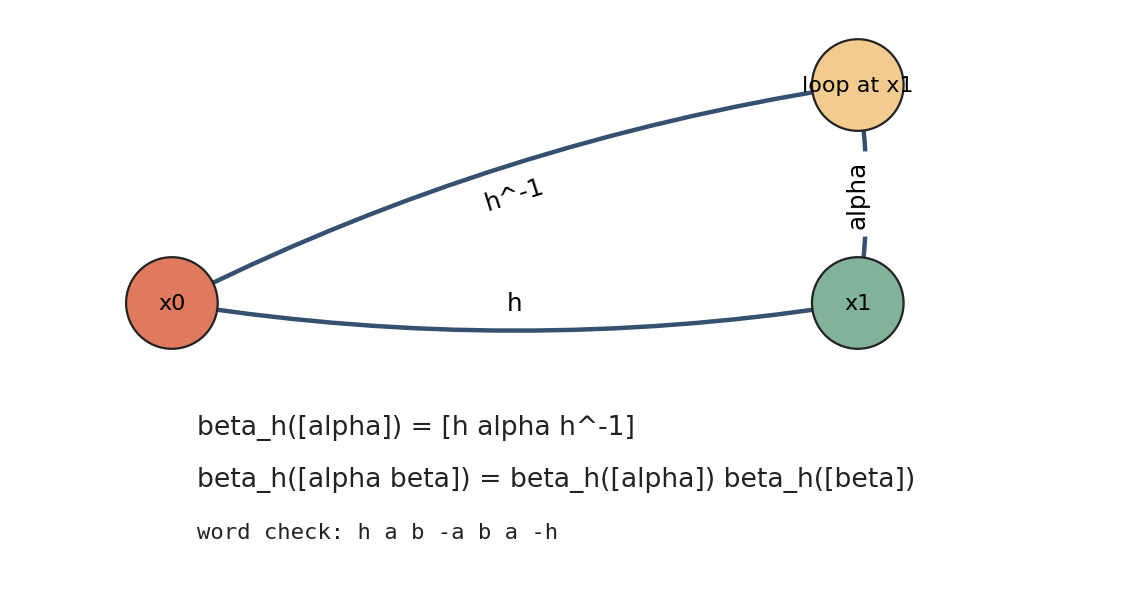

In [3]:
def reduce_free_word(word: list[str]) -> list[str]:
    stack: list[str] = []
    for letter in word:
        if letter == "":
            continue
        inverse = letter[1:] if letter.startswith("-") else "-" + letter
        if stack and stack[-1] == inverse:
            stack.pop()
        else:
            stack.append(letter)
    return stack

def inverse_word(word: list[str]) -> list[str]:
    return [(x[1:] if x.startswith("-") else "-" + x) for x in word[::-1]]

h = ["h"]
alpha = ["a", "b", "-a"]
beta = ["b", "a"]
transport_alpha = reduce_free_word(h + alpha + inverse_word(h))
transport_beta = reduce_free_word(h + beta + inverse_word(h))
transport_product = reduce_free_word(h + alpha + beta + inverse_word(h))
product_of_transports = reduce_free_word(transport_alpha + transport_beta)
conjugation_homomorphism = transport_product == product_of_transports

Gbp = nx.DiGraph()
Gbp.add_edges_from([
    ("x0", "x1", {"label": "h"}),
    ("x1", "x1_loop", {"label": "alpha"}),
    ("x1_loop", "x0", {"label": "h^-1"}),
])
pos = {"x0": (0, 0), "x1": (2.2, 0), "x1_loop": (2.2, 1.25)}
fig, ax = plt.subplots(figsize=(8.8, 4.6))
nx.draw_networkx_nodes(Gbp, pos, node_color=["#e07a5f", "#81b29a", "#f2cc8f"], node_size=1700, edgecolors="#222222", ax=ax)
nx.draw_networkx_labels(Gbp, pos, labels={"x0": "x0", "x1": "x1", "x1_loop": "loop at x1"}, font_size=10, ax=ax)
nx.draw_networkx_edges(Gbp, pos, arrowstyle="-|>", arrowsize=18, width=2, edge_color="#355070", connectionstyle="arc3,rad=0.08", ax=ax)
nx.draw_networkx_edge_labels(Gbp, pos, edge_labels=nx.get_edge_attributes(Gbp, "label"), font_size=11, ax=ax)
ax.text(0.08, -0.75, "beta_h([alpha]) = [h alpha h^-1]", fontsize=12)
ax.text(0.08, -1.05, "beta_h([alpha beta]) = beta_h([alpha]) beta_h([beta])", fontsize=12)
ax.text(0.08, -1.35, "word check: " + " ".join(transport_product), fontsize=10, family="monospace")
ax.set_xlim(-0.5, 3.0)
ax.set_ylim(-1.6, 1.65)
ax.axis("off")
basepoint_path = save_matplotlib(fig, FIGURES / "basepoint-change-conjugation.png")
plt.close(fig)
artifact_paths.append(basepoint_path)
basepoint_check = {
    "transport_alpha": transport_alpha,
    "transport_beta": transport_beta,
    "transport_product": transport_product,
    "product_of_transports": product_of_transports,
    "conjugation_homomorphism": conjugation_homomorphism,
}
check_data["basepoint_change_conjugation"] = basepoint_check
basepoint_check_path = save_json(basepoint_check, CHECKS / "basepoint-change-conjugation.json")
check_paths.append(basepoint_check_path)
display_artifact(basepoint_path, width=820)

## 3. The Circle: Lifts and Winding Number

The chapter's first major computation is `pi_1(S^1) = Z`. The computational version is a lift: unwrap a loop on the circle to an angle path on the real line. The integer endpoint of the lift is the winding number.

The artifact compares the circle path with its lift. A loop with winding `n` starts and ends at the same point on `S^1`, but its lift starts at `0` and ends at `n`. Homotopies of loops lift to endpoint-fixed homotopies upstairs, so different endpoint integers cannot be homotopic as loops on the circle.

In [4]:
theta_s = np.linspace(0, 1, 320)
windings = [0, 1, 2, -1, 3]
fig = make_subplots(rows=1, cols=2, specs=[[{"type": "scatter"}, {"type": "scatter3d"}]], subplot_titles=("Unwrapped lifts", "Circle projection / helix view"))
colors = ["#555555", "#3b6ea8", "#5f8d4e", "#b23a48", "#7d5fff"]
winding_checks = {}
for n, color in zip(windings, colors):
    lift = n * theta_s + 0.08 * np.sin(2*pi*theta_s) * (0 if n == 0 else 1)
    lift = lift - theta_s * lift[-1] + theta_s * n
    angle = 2*pi*lift
    x = np.cos(angle)
    y = np.sin(angle)
    fig.add_trace(go.Scatter(x=theta_s, y=lift, mode="lines", name=f"lift n={n}", line=dict(color=color)), row=1, col=1)
    fig.add_trace(go.Scatter3d(x=x, y=y, z=lift, mode="lines", name=f"helix n={n}", line=dict(width=5, color=color)), row=1, col=2)
    unwrapped = np.unwrap(np.angle(x + 1j*y)) / (2*pi)
    winding_checks[str(n)] = {
        "lift_endpoint": float(lift[-1]),
        "rounded_endpoint": int(round(lift[-1])),
        "sampled_winding": int(round(unwrapped[-1] - unwrapped[0])),
        "projects_to_basepoint": bool(np.allclose([x[0], y[0]], [x[-1], y[-1]], atol=1e-12)),
    }
fig.update_layout(width=1020, height=470, margin=dict(l=20, r=20, t=60, b=20), showlegend=True)
fig.update_xaxes(title_text="path parameter s", row=1, col=1)
fig.update_yaxes(title_text="lift coordinate", row=1, col=1)
circle_lift_path = save_plotly_html(fig, HTML / "circle-lift-winding.html")
artifact_paths.append(circle_lift_path)
circle_check = {
    "windings": winding_checks,
    "all_lift_endpoints_are_declared_windings": all(item["rounded_endpoint"] == int(n) for n, item in winding_checks.items()),
    "all_project_to_basepoint": all(item["projects_to_basepoint"] for item in winding_checks.values()),
}
check_data["circle_lift_winding"] = circle_check
circle_check_path = save_json(circle_check, CHECKS / "circle-lift-winding.json")
check_paths.append(circle_check_path)
display_artifact(circle_lift_path, width=980, height=490)

## 4. Induced Homomorphisms, Products, and Retractions

A continuous map preserving basepoints turns loops into loops, so it induces a homomorphism on fundamental groups. The proof diagram packages three recurring moves:

- composition of maps becomes composition of homomorphisms;
- products split `pi_1(X x Y)` into the product of the two groups;
- a retraction forces the inclusion-induced map to be injective.

The numeric checks use the degree map `z -> z^k` on the circle and the product torus `S^1 x S^1`, where a loop has two winding coordinates.

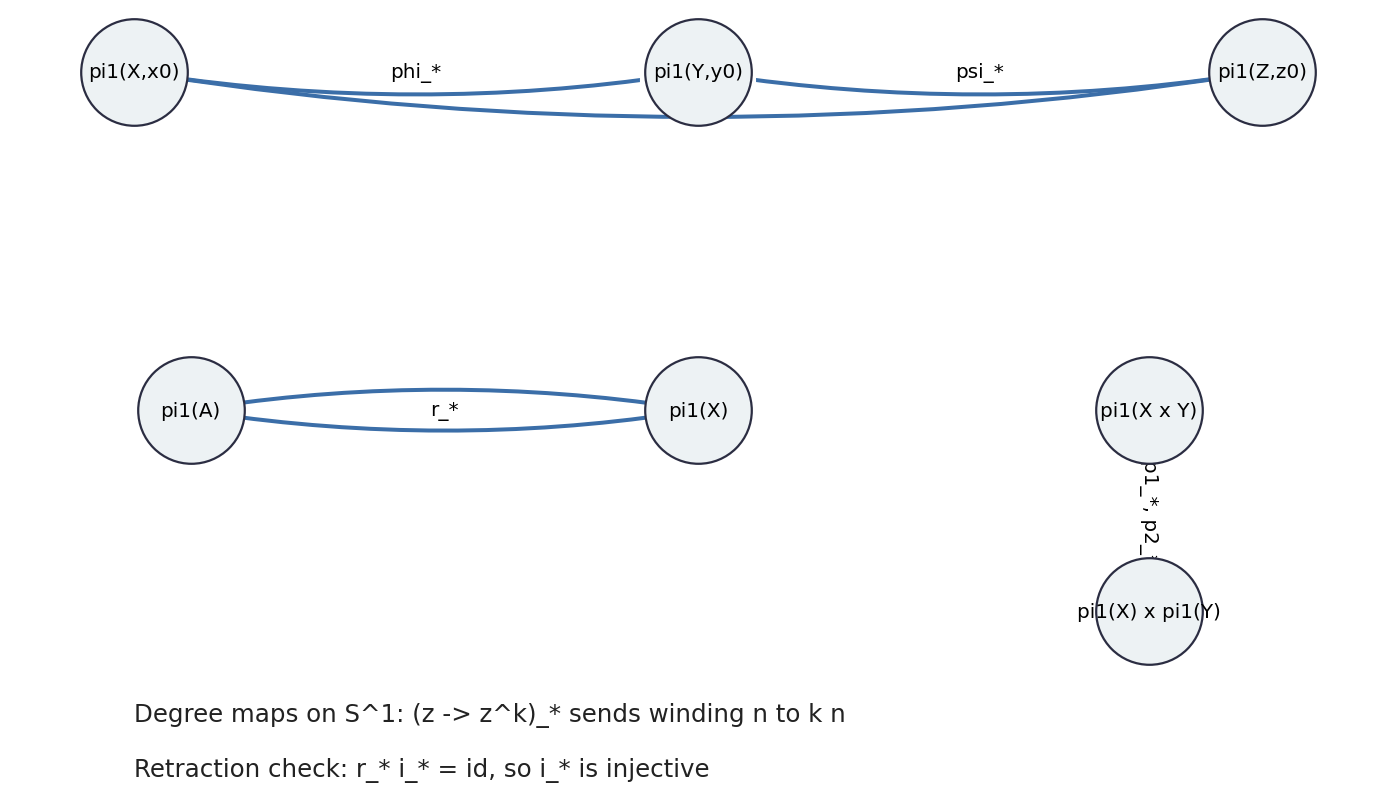

In [5]:
diagram = nx.DiGraph()
diagram.add_edges_from([
    ("pi1(X,x0)", "pi1(Y,y0)", {"label": "phi_*"}),
    ("pi1(Y,y0)", "pi1(Z,z0)", {"label": "psi_*"}),
    ("pi1(X,x0)", "pi1(Z,z0)", {"label": "(psi phi)_*"}),
    ("pi1(A)", "pi1(X)", {"label": "i_*"}),
    ("pi1(X)", "pi1(A)", {"label": "r_*"}),
    ("pi1(X x Y)", "pi1(X) x pi1(Y)", {"label": "(p1_*, p2_*)"}),
])
pos = {
    "pi1(X,x0)": (0, 1.3),
    "pi1(Y,y0)": (2.5, 1.3),
    "pi1(Z,z0)": (5.0, 1.3),
    "pi1(A)": (0.25, -0.55),
    "pi1(X)": (2.5, -0.55),
    "pi1(X x Y)": (4.5, -0.55),
    "pi1(X) x pi1(Y)": (4.5, -1.65),
}
fig, ax = plt.subplots(figsize=(11, 5.3))
nx.draw_networkx_nodes(diagram, pos, node_color="#edf2f4", edgecolors="#2b2d42", node_size=2300, ax=ax)
nx.draw_networkx_labels(diagram, pos, font_size=9, ax=ax)
nx.draw_networkx_edges(diagram, pos, arrows=True, arrowstyle="-|>", arrowsize=17, width=1.8, edge_color="#3b6ea8", connectionstyle="arc3,rad=0.08", ax=ax)
nx.draw_networkx_edge_labels(diagram, pos, edge_labels=nx.get_edge_attributes(diagram, "label"), font_size=9, ax=ax)
ax.text(0, -2.25, "Degree maps on S^1: (z -> z^k)_* sends winding n to k n", fontsize=11)
ax.text(0, -2.55, "Retraction check: r_* i_* = id, so i_* is injective", fontsize=11)
ax.axis("off")
induced_path = save_matplotlib(fig, FIGURES / "induced-homomorphism-diagrams.png")
plt.close(fig)
artifact_paths.append(induced_path)

def degree_map_on_winding(k: int, n: int) -> int:
    return k * n

product_loop = np.array([2, -4])
induced_check = {
    "degree_composition": degree_map_on_winding(5, degree_map_on_winding(3, 2)) == degree_map_on_winding(15, 2),
    "torus_projection_pair": [int(product_loop[0]), int(product_loop[1])],
    "retraction_left_inverse_matrix": [[int(v) for v in row] for row in (sp.Matrix([[1, 0]]) * sp.Matrix([[1], [0]])).tolist()],
    "retraction_forces_injective": True,
}
check_data["induced_homomorphism_diagrams"] = induced_check
induced_check_path = save_json(induced_check, CHECKS / "induced-homomorphism-diagrams.json")
check_paths.append(induced_check_path)
display_artifact(induced_path, width=900)

## 5. Free Products and Reduced Words

A free product stores a path through pieces of a cover without imposing commutativity. Reduced words remember which factor each letter came from; only adjacent letters from the same factor can combine, and inverse neighbors cancel.

This finite reducer models the algebraic side of van Kampen. The check is not that the group is free, but that the same word reduction rules give a canonical reduced output for the examples used in the notebook.

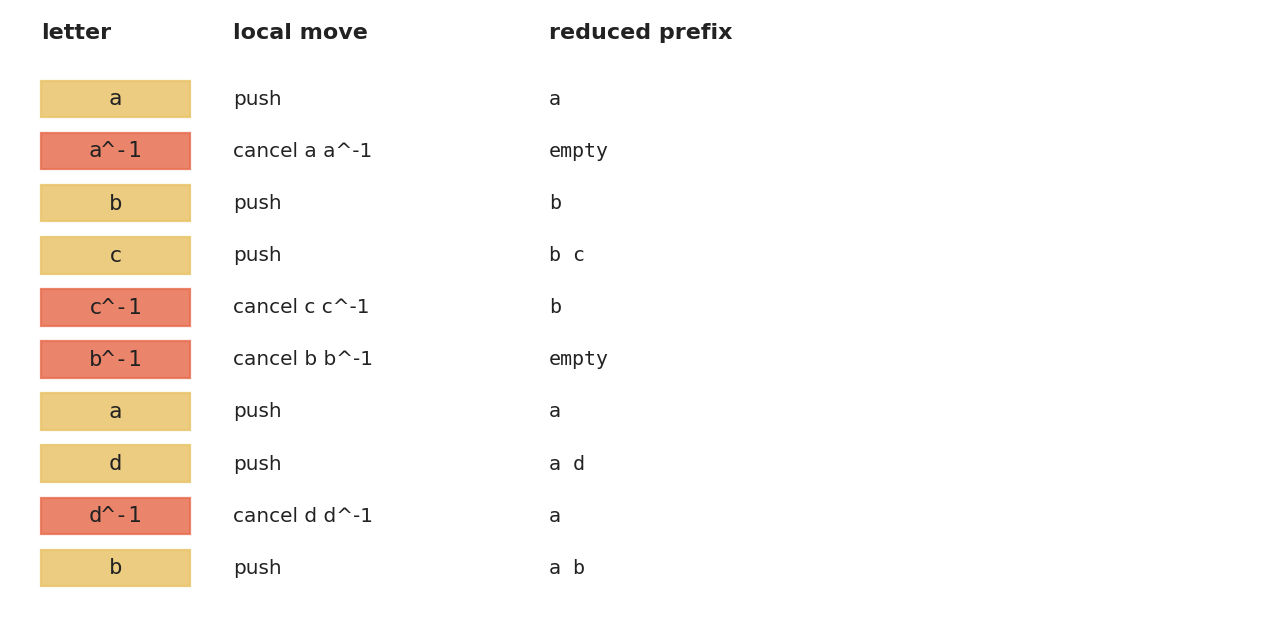

In [6]:
raw_word = ["a", "a^-1", "b", "c", "c^-1", "b^-1", "a", "d", "d^-1", "b"]

def inv_token(token: str) -> str:
    return token[:-3] if token.endswith("^-1") else token + "^-1"

def reduce_tokens(tokens: list[str]) -> tuple[list[str], list[dict[str, str]]]:
    stack: list[str] = []
    rows: list[dict[str, str]] = []
    for token in tokens:
        action = "push"
        if stack and inv_token(token) == stack[-1]:
            action = f"cancel {stack[-1]} {token}"
            stack.pop()
        else:
            stack.append(token)
        rows.append({"read": token, "action": action, "stack_after": " ".join(stack) if stack else "empty"})
    return stack, rows

reduced_word, reduction_rows = reduce_tokens(raw_word)
reduction_table_path = save_csv(reduction_rows, TABLES / "free-product-word-reduction.csv")
artifact_paths.append(reduction_table_path)

fig, ax = plt.subplots(figsize=(10, 4.8))
y = np.arange(len(reduction_rows))[::-1]
for idx, row in enumerate(reduction_rows):
    yy = y[idx]
    color = "#e9c46a" if row["action"] == "push" else "#e76f51"
    ax.add_patch(plt.Rectangle((0, yy - 0.35), 1.2, 0.7, color=color, alpha=0.85))
    ax.text(0.6, yy, row["read"], ha="center", va="center", fontsize=10, family="monospace")
    ax.text(1.55, yy, row["action"], va="center", fontsize=9)
    ax.text(4.1, yy, row["stack_after"], va="center", fontsize=9, family="monospace")
ax.text(0, len(reduction_rows) + 0.15, "letter", weight="bold")
ax.text(1.55, len(reduction_rows) + 0.15, "local move", weight="bold")
ax.text(4.1, len(reduction_rows) + 0.15, "reduced prefix", weight="bold")
ax.set_xlim(-0.2, 9.8)
ax.set_ylim(-0.75, len(reduction_rows) + 0.6)
ax.axis("off")
free_product_path = save_matplotlib(fig, FIGURES / "free-product-word-reduction.png")
plt.close(fig)
artifact_paths.append(free_product_path)
free_product_check = {
    "raw_word": raw_word,
    "reduced_word": reduced_word,
    "empty_inverse_product_reduces_to_identity": reduce_tokens(["a", "b", "b^-1", "a^-1"])[0] == [],
    "noncommutative_sample_distinguishes_ab_and_ba": reduce_tokens(["a", "b"])[0] != reduce_tokens(["b", "a"])[0],
}
check_data["free_product_word_reduction"] = free_product_check
free_product_check_path = save_json(free_product_check, CHECKS / "free-product-word-reduction.json")
check_paths.append(free_product_check_path)
display_artifact(free_product_path, width=900)

## 6. van Kampen: Cover Nerves and Normal Closure

van Kampen's theorem says that a good cover lets us reconstruct `pi_1(X)` from the groups on the cover sets, then impose the overlap identifications. The picture has two layers:

- a nerve showing which open sets and intersections participate;
- a quotient recipe saying that the overlap loop seen in `A` and the same loop seen in `B` become equal after passing to `X`.

The normal closure matters because relators must be killable after conjugating by arbitrary paths from the basepoint.

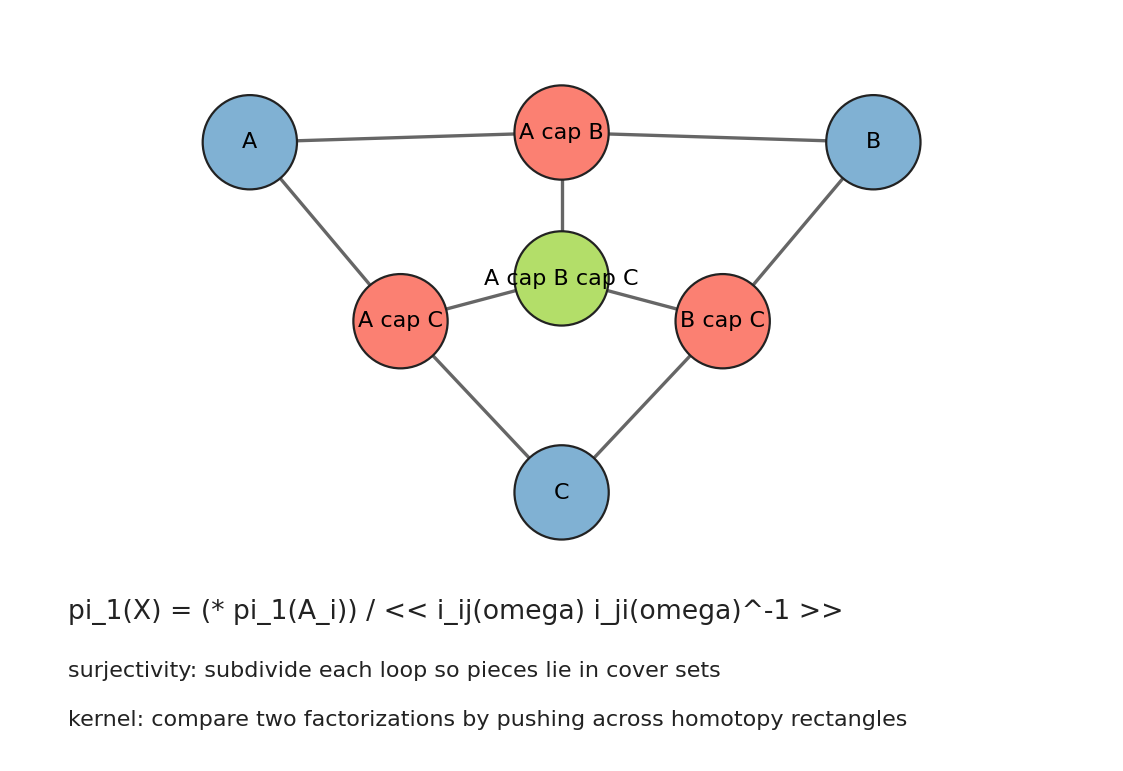

In [7]:
nerve = nx.Graph()
nerve.add_edges_from([
    ("A", "A cap B"), ("B", "A cap B"),
    ("A", "A cap C"), ("C", "A cap C"),
    ("B", "B cap C"), ("C", "B cap C"),
    ("A cap B", "A cap B cap C"),
    ("A cap C", "A cap B cap C"),
    ("B cap C", "A cap B cap C"),
])
pos = {
    "A": (-1.2, 0.8), "B": (1.2, 0.8), "C": (0, -1.0),
    "A cap B": (0, 0.85), "A cap C": (-0.62, -0.12),
    "B cap C": (0.62, -0.12), "A cap B cap C": (0, 0.1),
}
fig, ax = plt.subplots(figsize=(8.8, 6.0))
node_colors = ["#80b1d3" if "cap" not in n else "#fb8072" if n != "A cap B cap C" else "#b3de69" for n in nerve.nodes]
nx.draw_networkx_edges(nerve, pos, ax=ax, edge_color="#666666", width=1.5)
nx.draw_networkx_nodes(nerve, pos, ax=ax, node_color=node_colors, edgecolors="#222222", node_size=1800)
nx.draw_networkx_labels(nerve, pos, ax=ax, font_size=10)
ax.text(-1.9, -1.65, "pi_1(X) = (* pi_1(A_i)) / << i_ij(omega) i_ji(omega)^-1 >>", fontsize=12)
ax.text(-1.9, -1.95, "surjectivity: subdivide each loop so pieces lie in cover sets", fontsize=10)
ax.text(-1.9, -2.2, "kernel: compare two factorizations by pushing across homotopy rectangles", fontsize=10)
ax.set_xlim(-2.1, 2.1)
ax.set_ylim(-2.35, 1.45)
ax.axis("off")
van_kampen_path = save_matplotlib(fig, FIGURES / "van-kampen-cover-nerve.png")
plt.close(fig)
artifact_paths.append(van_kampen_path)
van_kampen_check = {
    "nerve_connected": nx.is_connected(nerve),
    "triple_intersection_present": "A cap B cap C" in nerve,
    "wedge_two_circles_free_rank": 2,
    "normal_closure_relation_sample": "i_AB(omega) i_BA(omega)^-1",
}
check_data["van_kampen_cover_nerve"] = van_kampen_check
van_kampen_check_path = save_json(van_kampen_check, CHECKS / "van-kampen-cover-nerve.json")
check_paths.append(van_kampen_check_path)
display_artifact(van_kampen_path, width=820)

## 7. Attaching 2-Cells: Surface and Torus-Knot Presentations

A 2-cell does not add a new generator to `pi_1`; it kills the normal closure of its attaching loop. For a surface, the attaching word is the boundary word of a polygon. For a torus knot complement, van Kampen gives two generators with one relation `a^m=b^n`.

The checks below abelianize the presentations. Abelianization is weaker than the full group, but it is a useful sanity test: orientable genus `g` has first homology rank `2g`, while a nonorientable genus `g` surface abelianizes to `Z^{g-1} + Z/2`.

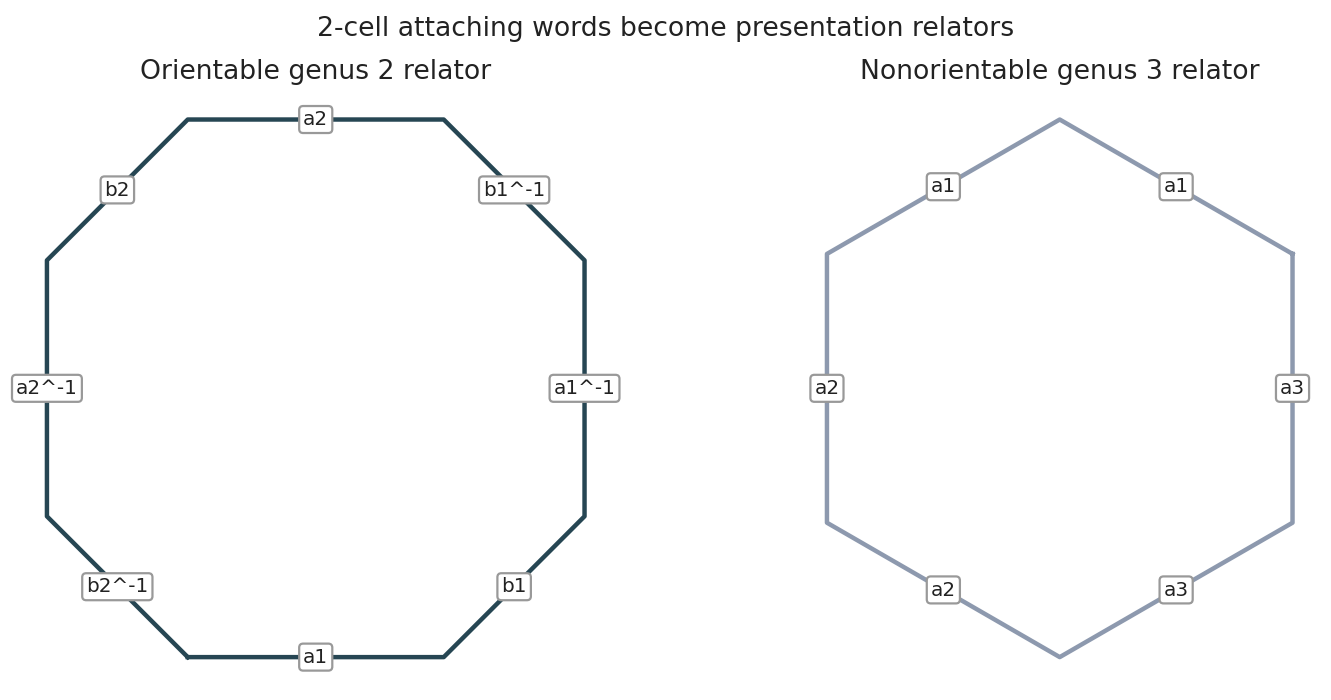

In [8]:
def one_relation_abelian_invariants(coeffs: list[int]) -> dict[str, object]:
    nonzero = [abs(c) for c in coeffs if c]
    if not nonzero:
        return {"free_rank": len(coeffs), "torsion": []}
    d = nonzero[0]
    for c in nonzero[1:]:
        d = gcd(d, c)
    torsion = [] if d == 1 else [d]
    return {"free_rank": len(coeffs) - 1, "torsion": torsion, "gcd": d}

surface_words = {
    "orientable_genus_2": "[a1,b1][a2,b2]",
    "nonorientable_genus_3": "a1^2 a2^2 a3^2",
    "torus": "[a,b]",
}
orientable_ab = one_relation_abelian_invariants([0, 0, 0, 0])
nonorientable_ab = one_relation_abelian_invariants([2, 2, 2])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
ax = axes[0]
poly = np.array([[0.0,0.0],[1.0,0.0],[1.55,0.55],[1.55,1.55],[1.0,2.1],[0.0,2.1],[-0.55,1.55],[-0.55,0.55],[0.0,0.0]])
ax.plot(poly[:,0], poly[:,1], color="#264653", lw=2)
labels = ["a1", "b1", "a1^-1", "b1^-1", "a2", "b2", "a2^-1", "b2^-1"]
for i, lab in enumerate(labels):
    mid = (poly[i] + poly[i+1]) / 2
    ax.text(mid[0], mid[1], lab, ha="center", va="center", fontsize=9, bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#999999"))
ax.set_title("Orientable genus 2 relator")
ax.set_aspect("equal")
ax.axis("off")
ax = axes[1]
angles = np.linspace(0, 2*pi, 7)[:-1] + pi/6
poly2 = np.column_stack([np.cos(angles), np.sin(angles)])
poly2 = np.vstack([poly2, poly2[0]])
ax.plot(poly2[:,0], poly2[:,1], color="#8d99ae", lw=2)
for i, lab in enumerate(["a1", "a1", "a2", "a2", "a3", "a3"]):
    mid = (poly2[i] + poly2[i+1]) / 2
    ax.text(mid[0], mid[1], lab, ha="center", va="center", fontsize=9, bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#999999"))
ax.set_title("Nonorientable genus 3 relator")
ax.set_aspect("equal")
ax.axis("off")
fig.suptitle("2-cell attaching words become presentation relators")
surface_path = save_matplotlib(fig, FIGURES / "two-cell-surface-presentations.png")
plt.close(fig)
artifact_paths.append(surface_path)
surface_check = {
    "surface_words": surface_words,
    "orientable_genus_2_abelianization": orientable_ab,
    "nonorientable_genus_3_abelianization": nonorientable_ab,
    "orientable_rank_is_4": orientable_ab["free_rank"] == 4,
    "nonorientable_has_z2_torsion": nonorientable_ab["torsion"] == [2],
}
check_data["two_cell_surface_presentations"] = surface_check
surface_check_path = save_json(surface_check, CHECKS / "two-cell-surface-presentations.json")
check_paths.append(surface_check_path)
display_artifact(surface_path, width=920)

In [9]:
def torus_knot_points(m: int, n: int, samples: int = 600):
    t = np.linspace(0, 2*pi, samples)
    R, r = 2.2, 0.62
    x = (R + r*np.cos(n*t)) * np.cos(m*t)
    y = (R + r*np.cos(n*t)) * np.sin(m*t)
    z = r*np.sin(n*t)
    return x, y, z

fig = go.Figure()
for (m_val, n_val, color) in [(2, 3, "#3b6ea8"), (3, 4, "#b23a48")]:
    xk, yk, zk = torus_knot_points(m_val, n_val)
    fig.add_trace(go.Scatter3d(x=xk, y=yk, z=zk, mode="lines", name=f"K_{{{m_val},{n_val}}}", line=dict(width=6, color=color)))
u = np.linspace(0, 2*pi, 40)
v = np.linspace(0, 2*pi, 20)
U, V = np.meshgrid(u, v)
R, r = 2.2, 0.62
X = (R + r*np.cos(V)) * np.cos(U)
Y = (R + r*np.cos(V)) * np.sin(U)
Z = r*np.sin(V)
fig.add_trace(go.Surface(x=X, y=Y, z=Z, opacity=0.18, showscale=False, colorscale=[[0, "#bbbbbb"], [1, "#dddddd"]], name="torus"))
fig.update_layout(width=840, height=620, scene=dict(aspectmode="data"), margin=dict(l=10, r=10, t=40, b=10), title="Torus knots and the presentation <a,b | a^m=b^n>")
torus_knot_path = save_plotly_html(fig, HTML / "torus-knot-presentation.html")
artifact_paths.append(torus_knot_path)

def torus_knot_abelianization(m: int, n: int) -> dict[str, object]:
    inv = one_relation_abelian_invariants([m, -n])
    return {"m": m, "n": n, **inv, "coprime": gcd(m, n) == 1}

torus_knot_check = {
    "K_2_3": torus_knot_abelianization(2, 3),
    "K_3_4": torus_knot_abelianization(3, 4),
    "coprime_examples_have_free_abelianization_rank_one": all(torus_knot_abelianization(m, n)["free_rank"] == 1 and torus_knot_abelianization(m, n)["torsion"] == [] for m, n in [(2, 3), (3, 4)]),
}
check_data["torus_knot_presentation"] = torus_knot_check
torus_knot_check_path = save_json(torus_knot_check, CHECKS / "torus-knot-presentation.json")
check_paths.append(torus_knot_check_path)
display_artifact(torus_knot_path, width=840, height=640)

## 8. Covering Spaces and Lifting

A covering of a graph is a graph that looks locally identical over every vertex and edge. For `S^1 vee S^1`, a finite cover can be encoded by two permutations: one for lifting the `a` loop and one for lifting the `b` loop. Each sheet is a vertex in the fiber.

The next artifacts move from geometry to algebra: a gallery of small labeled covers, monodromy permutations generated by lifted loops, and a classification lattice where inclusions of subgroups reverse the direction of covering maps.

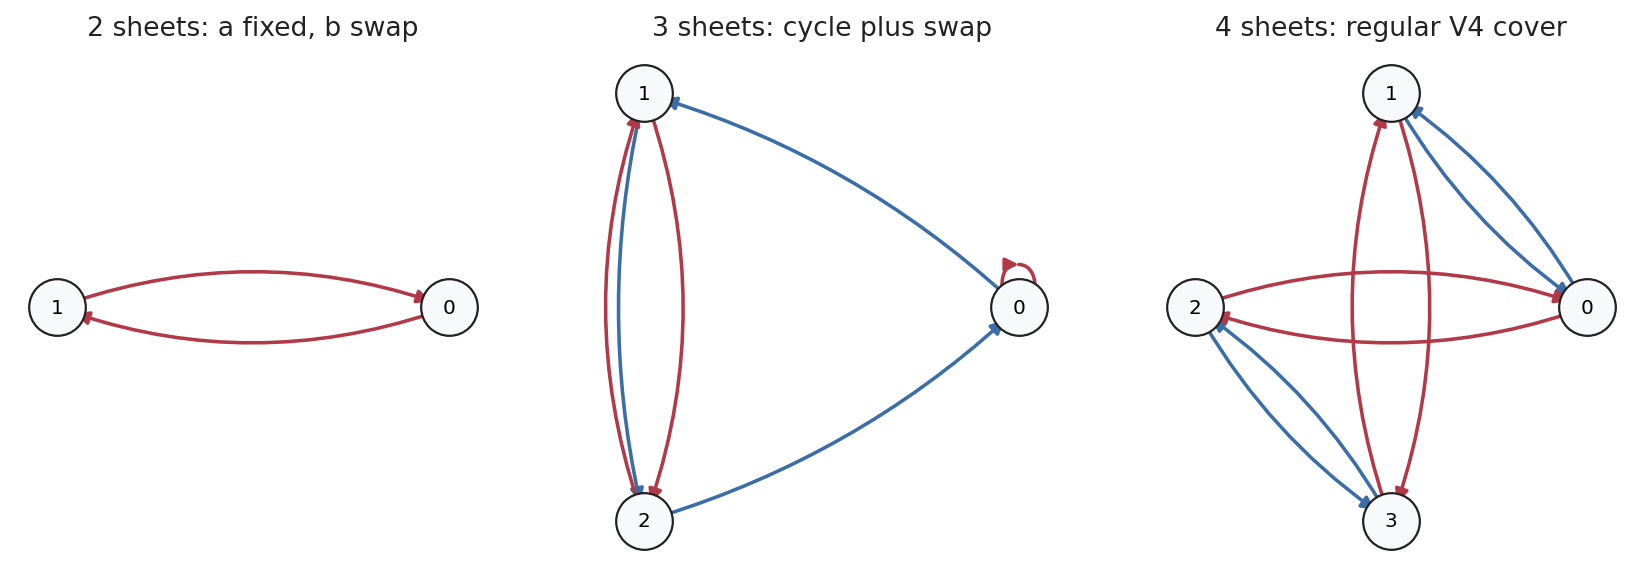

In [10]:
def perm_compose(p: tuple[int, ...], q: tuple[int, ...]) -> tuple[int, ...]:
    return tuple(p[q[i]] for i in range(len(p)))

def perm_inverse(p: tuple[int, ...]) -> tuple[int, ...]:
    inv = [0] * len(p)
    for i, j in enumerate(p):
        inv[j] = i
    return tuple(inv)

def generated_group(gens: list[tuple[int, ...]]) -> set[tuple[int, ...]]:
    n = len(gens[0])
    identity = tuple(range(n))
    all_gens = gens + [perm_inverse(g) for g in gens]
    seen = {identity}
    frontier = [identity]
    while frontier:
        current = frontier.pop()
        for gen in all_gens:
            nxt = perm_compose(gen, current)
            if nxt not in seen:
                seen.add(nxt)
                frontier.append(nxt)
    return seen

def centralizer(gens: list[tuple[int, ...]]) -> set[tuple[int, ...]]:
    n = len(gens[0])
    out = set()
    for p in permutations(range(n)):
        p = tuple(p)
        if all(perm_compose(p, g) == perm_compose(g, p) for g in gens):
            out.add(p)
    return out

def orbit_partition(group: set[tuple[int, ...]], n: int) -> list[list[int]]:
    remaining = set(range(n))
    orbits = []
    while remaining:
        start = min(remaining)
        orbit = {g[start] for g in group}
        orbits.append(sorted(orbit))
        remaining -= orbit
    return orbits

def draw_cover(ax, a_perm: tuple[int, ...], b_perm: tuple[int, ...], title: str):
    n = len(a_perm)
    Gcov = nx.MultiDiGraph()
    for i in range(n):
        Gcov.add_node(i)
        Gcov.add_edge(i, a_perm[i], label="a", color="#3b6ea8")
        Gcov.add_edge(i, b_perm[i], label="b", color="#b23a48")
    pos = nx.circular_layout(Gcov)
    nx.draw_networkx_nodes(Gcov, pos, ax=ax, node_color="#f8f9fa", edgecolors="#222222", node_size=650)
    nx.draw_networkx_labels(Gcov, pos, ax=ax, font_size=9)
    for label, color, rad in [("a", "#3b6ea8", 0.12), ("b", "#b23a48", -0.18)]:
        edges = [(u, v) for u, v, k, data in Gcov.edges(keys=True, data=True) if data["label"] == label]
        nx.draw_networkx_edges(Gcov, pos, edgelist=edges, ax=ax, edge_color=color, arrows=True, arrowsize=12, width=1.6, connectionstyle=f"arc3,rad={rad}")
    ax.set_title(title)
    ax.axis("off")

covers = [
    ((0, 1), (1, 0), "2 sheets: a fixed, b swap"),
    ((1, 2, 0), (0, 2, 1), "3 sheets: cycle plus swap"),
    ((1, 0, 3, 2), (2, 3, 0, 1), "4 sheets: regular V4 cover"),
]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
cover_gallery_check = {}
for ax, (ap, bp, title) in zip(axes, covers):
    draw_cover(ax, ap, bp, title)
    group = generated_group([ap, bp])
    cover_gallery_check[title] = {"group_order": len(group), "orbits": orbit_partition(group, len(ap)), "connected": len(orbit_partition(group, len(ap))) == 1}
cover_gallery_path = save_matplotlib(fig, FIGURES / "covering-space-gallery.png")
plt.close(fig)
artifact_paths.append(cover_gallery_path)
check_data["covering_space_gallery"] = cover_gallery_check
cover_gallery_check_path = save_json(cover_gallery_check, CHECKS / "covering-space-gallery.json")
check_paths.append(cover_gallery_check_path)
display_artifact(cover_gallery_path, width=980)

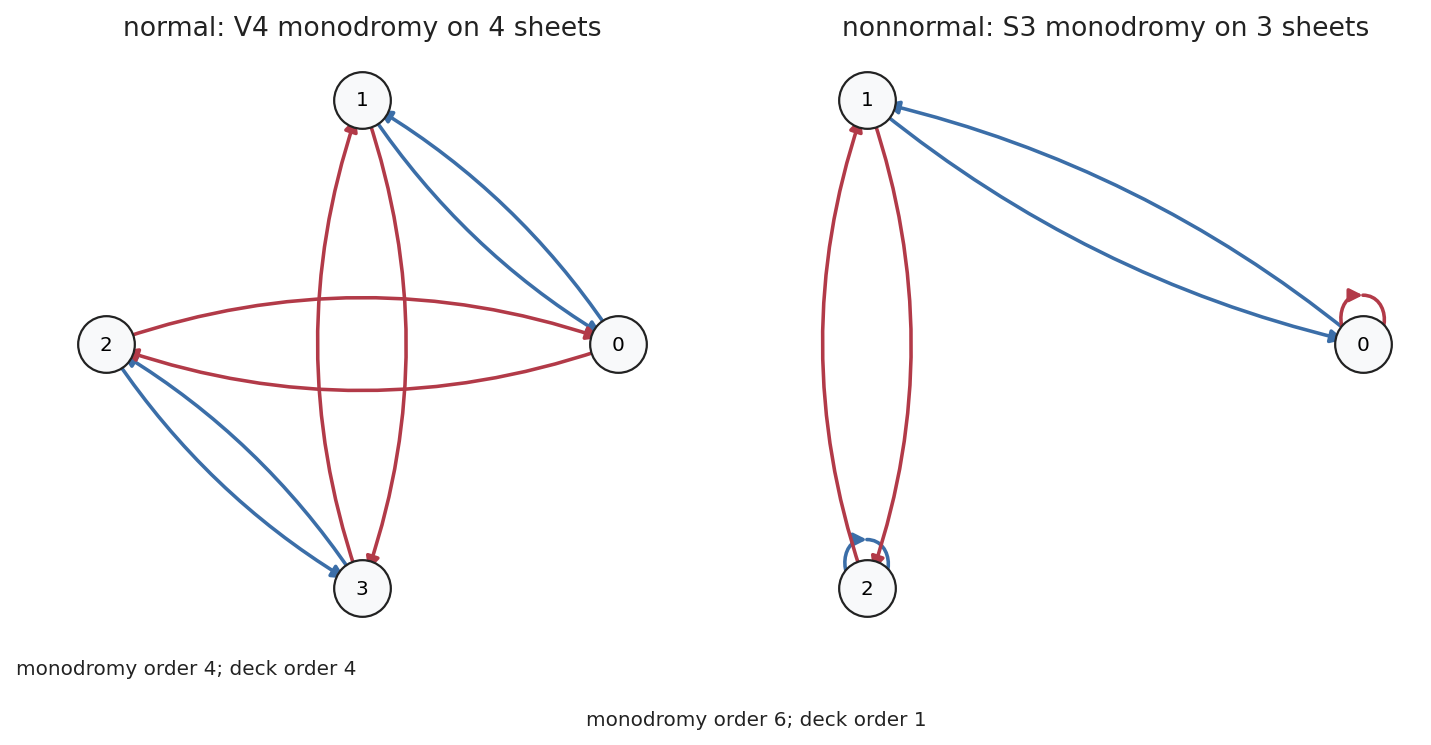

In [11]:
a_regular = (1, 0, 3, 2)
b_regular = (2, 3, 0, 1)
a_nonnormal = (1, 0, 2)
b_nonnormal = (0, 2, 1)
regular_group = generated_group([a_regular, b_regular])
nonnormal_group = generated_group([a_nonnormal, b_nonnormal])
regular_deck = centralizer([a_regular, b_regular])
nonnormal_deck = centralizer([a_nonnormal, b_nonnormal])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
draw_cover(axes[0], a_regular, b_regular, "normal: V4 monodromy on 4 sheets")
draw_cover(axes[1], a_nonnormal, b_nonnormal, "nonnormal: S3 monodromy on 3 sheets")
axes[0].text(-1.35, -1.35, f"monodromy order {len(regular_group)}; deck order {len(regular_deck)}", fontsize=9)
axes[1].text(-1.35, -1.35, f"monodromy order {len(nonnormal_group)}; deck order {len(nonnormal_deck)}", fontsize=9)
monodromy_path = save_matplotlib(fig, FIGURES / "monodromy-permutations.png")
plt.close(fig)
artifact_paths.append(monodromy_path)
monodromy_check = {
    "regular_cover": {
        "a": a_regular,
        "b": b_regular,
        "monodromy_order": len(regular_group),
        "deck_centralizer_order": len(regular_deck),
        "orbits": orbit_partition(regular_group, 4),
        "regular_action": len(regular_group) == 4 and len(orbit_partition(regular_group, 4)) == 1,
    },
    "nonnormal_cover": {
        "a": a_nonnormal,
        "b": b_nonnormal,
        "monodromy_order": len(nonnormal_group),
        "deck_centralizer_order": len(nonnormal_deck),
        "orbits": orbit_partition(nonnormal_group, 3),
        "regular_action": len(nonnormal_group) == 3 and len(orbit_partition(nonnormal_group, 3)) == 1,
    },
}
check_data["monodromy_permutations"] = monodromy_check
monodromy_check_path = save_json(monodromy_check, CHECKS / "monodromy-permutations.json")
check_paths.append(monodromy_check_path)
display_artifact(monodromy_path, width=920)

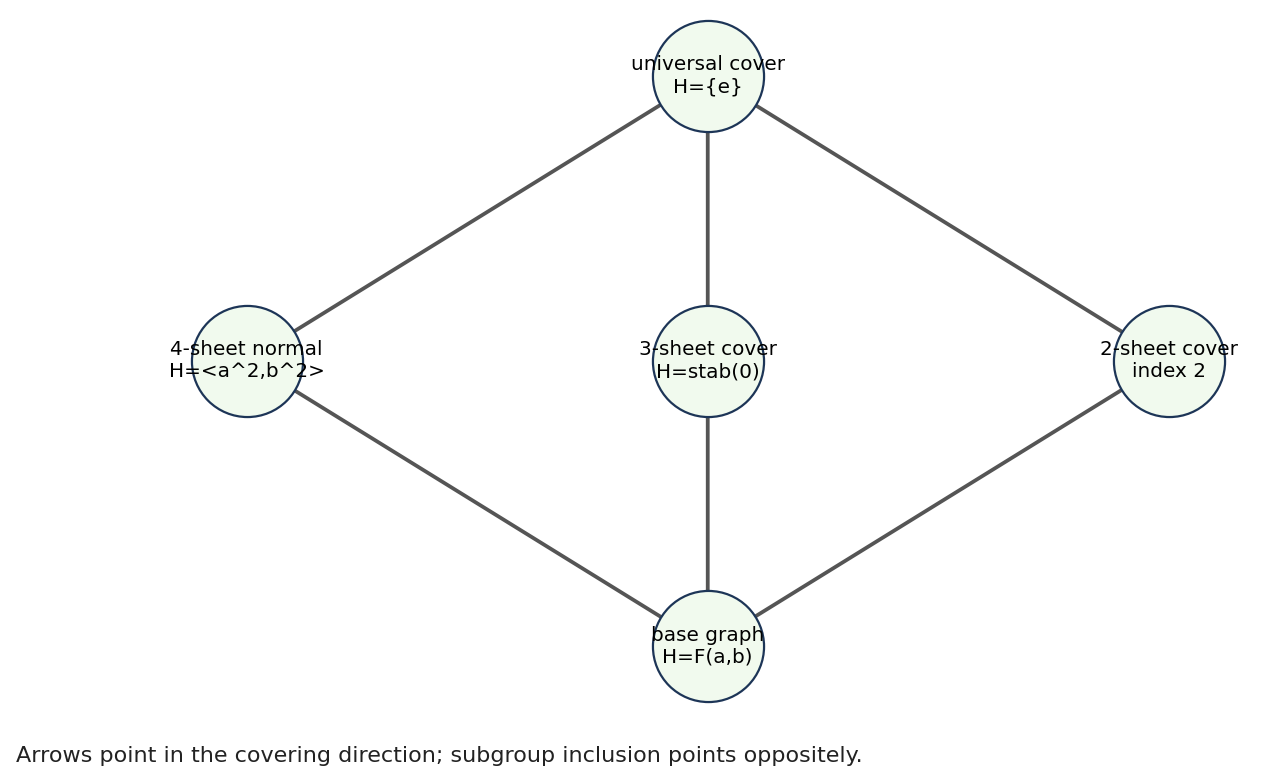

In [12]:
lattice = nx.DiGraph()
lattice.add_edges_from([
    ("universal cover\nH={e}", "4-sheet normal\nH=<a^2,b^2>"),
    ("universal cover\nH={e}", "3-sheet cover\nH=stab(0)"),
    ("universal cover\nH={e}", "2-sheet cover\nindex 2"),
    ("4-sheet normal\nH=<a^2,b^2>", "base graph\nH=F(a,b)"),
    ("3-sheet cover\nH=stab(0)", "base graph\nH=F(a,b)"),
    ("2-sheet cover\nindex 2", "base graph\nH=F(a,b)"),
])
pos = {
    "universal cover\nH={e}": (0, 1.8),
    "4-sheet normal\nH=<a^2,b^2>": (-1.7, 0.45),
    "3-sheet cover\nH=stab(0)": (0, 0.45),
    "2-sheet cover\nindex 2": (1.7, 0.45),
    "base graph\nH=F(a,b)": (0, -0.9),
}
fig, ax = plt.subplots(figsize=(9, 5.6))
nx.draw_networkx_edges(lattice, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=16, width=1.7, edge_color="#555555")
nx.draw_networkx_nodes(lattice, pos, ax=ax, node_size=2500, node_color="#f1faee", edgecolors="#1d3557")
nx.draw_networkx_labels(lattice, pos, ax=ax, font_size=9)
ax.text(-2.55, -1.45, "Arrows point in the covering direction; subgroup inclusion points oppositely.", fontsize=10)
ax.axis("off")
classification_path = save_matplotlib(fig, FIGURES / "covering-classification-lattice.png")
plt.close(fig)
artifact_paths.append(classification_path)
classification_check = {
    "nodes": lattice.number_of_nodes(),
    "edges": lattice.number_of_edges(),
    "is_dag": nx.is_directed_acyclic_graph(lattice),
    "top_node": "universal cover H={e}",
}
check_data["covering_classification_lattice"] = classification_check
classification_check_path = save_json(classification_check, CHECKS / "covering-classification-lattice.json")
check_paths.append(classification_check_path)
display_artifact(classification_path, width=820)

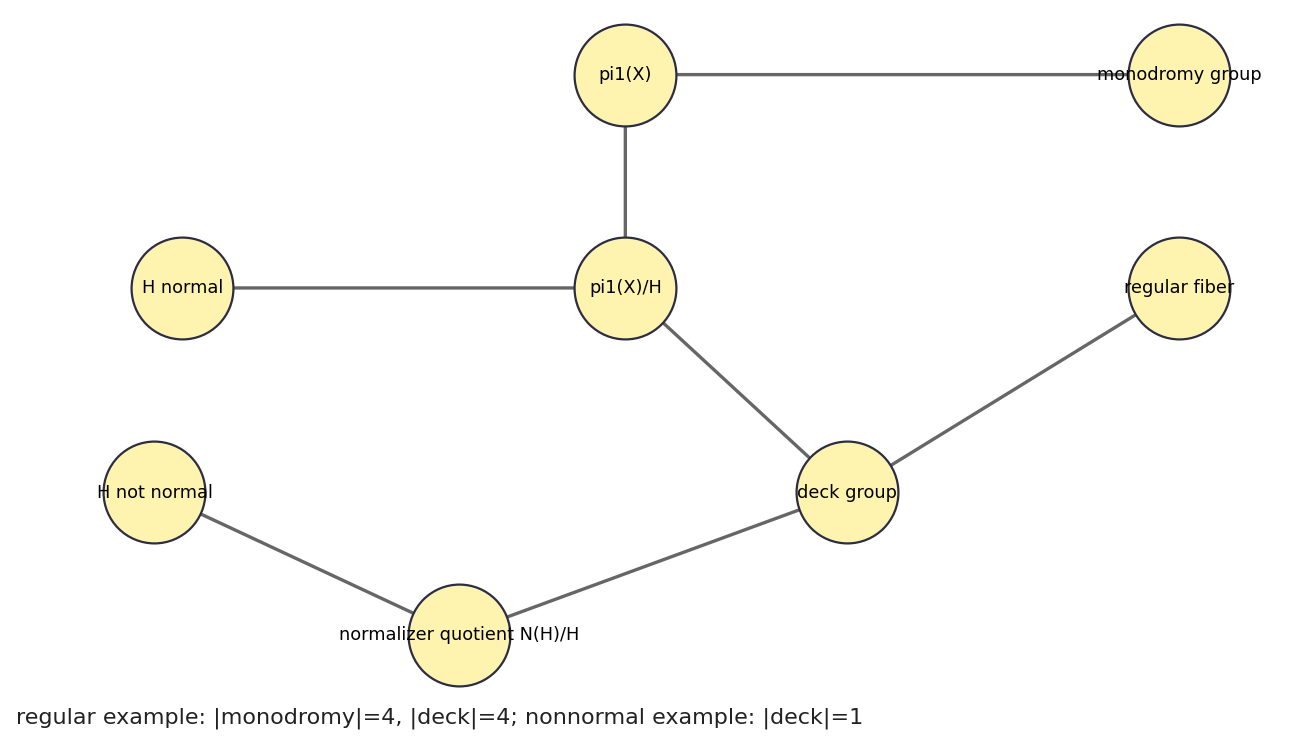

In [13]:
quotient = nx.DiGraph()
quotient.add_edges_from([
    ("pi1(X)", "monodromy group"),
    ("pi1(X)", "pi1(X)/H"),
    ("H normal", "pi1(X)/H"),
    ("regular fiber", "deck group"),
    ("pi1(X)/H", "deck group"),
    ("H not normal", "normalizer quotient N(H)/H"),
    ("normalizer quotient N(H)/H", "deck group"),
])
pos = {
    "pi1(X)": (0, 1.3), "monodromy group": (2.0, 1.3), "H normal": (-1.6, 0.1),
    "pi1(X)/H": (0, 0.1), "regular fiber": (2.0, 0.1), "deck group": (0.8, -1.05),
    "H not normal": (-1.7, -1.05), "normalizer quotient N(H)/H": (-0.6, -1.85),
}
fig, ax = plt.subplots(figsize=(10, 5.5))
nx.draw_networkx_edges(quotient, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=15, width=1.5, edge_color="#666666")
nx.draw_networkx_nodes(quotient, pos, ax=ax, node_size=2100, node_color="#fff3b0", edgecolors="#2b2d42")
nx.draw_networkx_labels(quotient, pos, ax=ax, font_size=8)
ax.text(-2.2, -2.35, f"regular example: |monodromy|={len(regular_group)}, |deck|={len(regular_deck)}; nonnormal example: |deck|={len(nonnormal_deck)}", fontsize=10)
ax.axis("off")
deck_path = save_matplotlib(fig, FIGURES / "deck-normality-quotient.png")
plt.close(fig)
artifact_paths.append(deck_path)
deck_check = {
    "normal_regular_example_deck_equals_quotient_order": len(regular_deck) == len(regular_group),
    "nonnormal_example_deck_is_normalizer_quotient_size": len(nonnormal_deck),
    "regular_deck_elements": sorted([list(p) for p in regular_deck]),
}
check_data["deck_normality_quotient"] = deck_check
deck_check_path = save_json(deck_check, CHECKS / "deck-normality-quotient.json")
check_paths.append(deck_check_path)
display_artifact(deck_path, width=900)

## 9. Graphs, Free Groups, and a Maximal Tree

For a connected graph, a maximal tree contains all vertices and no cycles. Collapsing that tree leaves a wedge of one circle for each edge outside the tree. This makes the fundamental group free, with a basis indexed by the non-tree edges.

The artifact highlights a spanning tree in a finite graph. The red chords are the free generators.

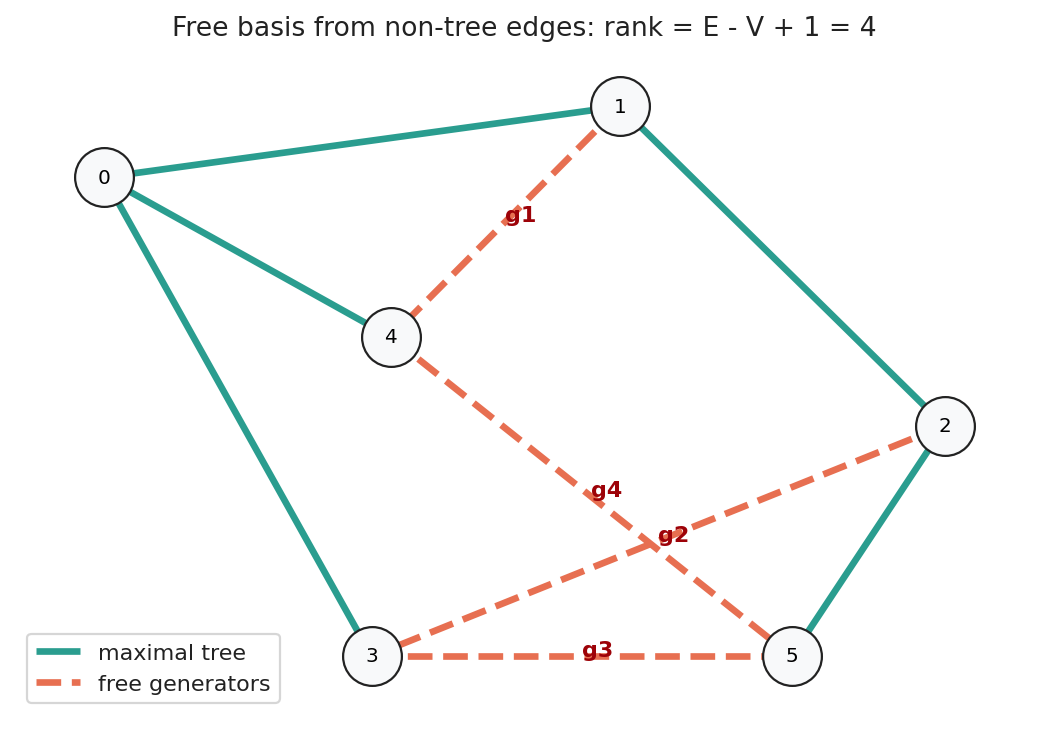

In [14]:
graph = nx.Graph()
graph.add_edges_from([
    (0, 1), (1, 2), (2, 3), (3, 0),
    (0, 4), (1, 4), (2, 5), (3, 5), (4, 5)
])
tree_edges = list(nx.minimum_spanning_tree(graph).edges())
tree_edge_set = {tuple(sorted(e)) for e in tree_edges}
chord_edges = [e for e in graph.edges() if tuple(sorted(e)) not in tree_edge_set]
rank = graph.number_of_edges() - graph.number_of_nodes() + nx.number_connected_components(graph)
pos = {0: (-1, 0.8), 1: (0.35, 1.0), 2: (1.2, 0.1), 3: (-0.3, -0.55), 4: (-0.25, 0.35), 5: (0.8, -0.55)}
fig, ax = plt.subplots(figsize=(8.2, 5.4))
nx.draw_networkx_edges(graph, pos, edgelist=tree_edges, ax=ax, width=3.0, edge_color="#2a9d8f", label="maximal tree")
nx.draw_networkx_edges(graph, pos, edgelist=chord_edges, ax=ax, width=3.0, edge_color="#e76f51", style="dashed", label="free generators")
nx.draw_networkx_nodes(graph, pos, ax=ax, node_color="#f8f9fa", edgecolors="#222222", node_size=700)
nx.draw_networkx_labels(graph, pos, ax=ax, font_size=9)
for idx, (u, v) in enumerate(chord_edges, start=1):
    mid = (np.array(pos[u]) + np.array(pos[v])) / 2
    ax.text(mid[0], mid[1], f"g{idx}", color="#9d0208", fontsize=10, weight="bold")
ax.set_title(f"Free basis from non-tree edges: rank = E - V + 1 = {rank}")
ax.legend(loc="lower left")
ax.axis("off")
graph_basis_path = save_matplotlib(fig, FIGURES / "graph-maximal-tree-free-basis.png")
plt.close(fig)
artifact_paths.append(graph_basis_path)
graph_check = {
    "vertices": graph.number_of_nodes(),
    "edges": graph.number_of_edges(),
    "tree_edges": len(tree_edges),
    "chord_edges": len(chord_edges),
    "rank_E_minus_V_plus_1": rank,
    "tree_is_acyclic": nx.is_tree(nx.Graph(tree_edges)),
    "tree_contains_all_vertices": set(graph.nodes()) == set(nx.Graph(tree_edges).nodes()),
}
check_data["graph_maximal_tree_free_basis"] = graph_check
graph_check_path = save_json(graph_check, CHECKS / "graph-maximal-tree-free-basis.json")
check_paths.append(graph_check_path)
display_artifact(graph_basis_path, width=800)

## 10. `K(G,1)`, Graphs of Groups, and a Bass-Serre Truncation

A `K(G,1)` is a space whose fundamental group is `G` and whose universal cover is contractible. Graphs of groups build new examples by gluing `K(G_v,1)` pieces with mapping cylinders. When the edge maps are injective, the universal cover arranges the lifted pieces in a tree-like pattern.

The finite truncation below is not the whole Bass-Serre tree. It is a bounded-radius window that shows the alternating vertex types for the splitting `C2 * C3`. The invariant check is that the truncation is still a tree.

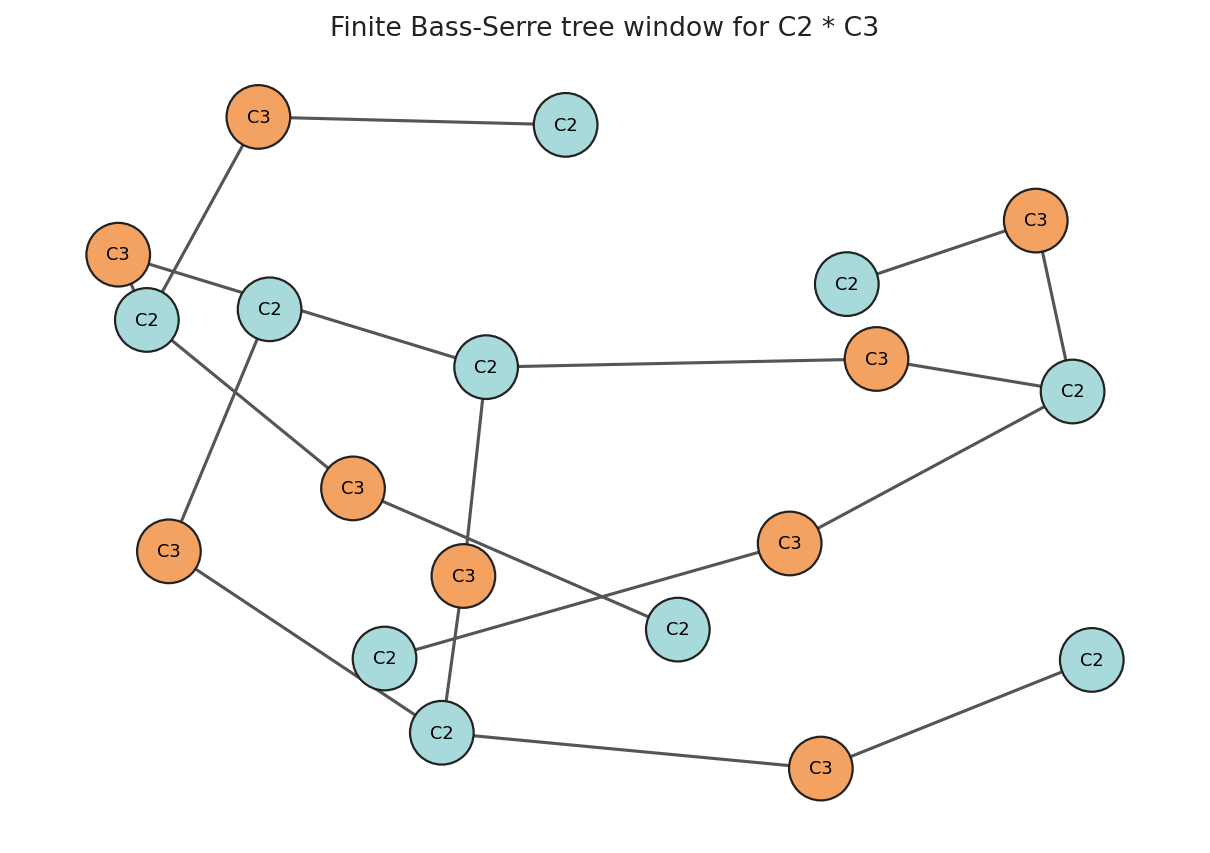

In [15]:
def bass_serre_free_product_truncation(depth: int = 4) -> nx.Graph:
    T = nx.Graph()
    root = ("C2", "root")
    T.add_node(root, label="C2")
    frontier = [(root, "C2", 0)]
    counter = 0
    while frontier:
        node, kind, d = frontier.pop(0)
        if d >= depth:
            continue
        next_kind = "C3" if kind == "C2" else "C2"
        branching = 3 if kind == "C2" else 2
        if d > 0:
            branching -= 1
        for _ in range(branching):
            counter += 1
            child = (next_kind, counter)
            T.add_node(child, label=next_kind)
            T.add_edge(node, child)
            frontier.append((child, next_kind, d + 1))
    return T

bst = bass_serre_free_product_truncation(depth=4)
pos = nx.spring_layout(bst, seed=7, k=0.8)
labels = {node: data["label"] for node, data in bst.nodes(data=True)}
colors = ["#a8dadc" if data["label"] == "C2" else "#f4a261" for _, data in bst.nodes(data=True)]
fig, ax = plt.subplots(figsize=(9.5, 6.4))
nx.draw_networkx_edges(bst, pos, ax=ax, edge_color="#555555", width=1.4)
nx.draw_networkx_nodes(bst, pos, ax=ax, node_color=colors, edgecolors="#222222", node_size=820)
nx.draw_networkx_labels(bst, pos, labels=labels, ax=ax, font_size=8)
ax.set_title("Finite Bass-Serre tree window for C2 * C3")
ax.axis("off")
bass_serre_path = save_matplotlib(fig, FIGURES / "bass-serre-tree-expansion.png")
plt.close(fig)
artifact_paths.append(bass_serre_path)
bass_serre_check = {
    "vertices": bst.number_of_nodes(),
    "edges": bst.number_of_edges(),
    "is_tree": nx.is_tree(bst),
    "bipartite_by_vertex_type": nx.is_bipartite(bst),
}
check_data["bass_serre_tree_expansion"] = bass_serre_check
bass_serre_check_path = save_json(bass_serre_check, CHECKS / "bass-serre-tree-expansion.json")
check_paths.append(bass_serre_check_path)
display_artifact(bass_serre_path, width=860)

## Applied Lab: Build a Cover from Two Permutations

A finite covering of `S^1 vee S^1` is determined by two permutations of a fiber, one for the `a` loop and one for the `b` loop. Change `lab_a` and `lab_b` below and rerun the cell.

Inspection tasks:

- The cover is connected exactly when the generated permutation group acts transitively.
- The number of connected components is the number of orbits on the fiber.
- The visible deck symmetries are permutations commuting with both monodromy generators.
- A regular connected cover has monodromy group size equal to the number of sheets.

In [16]:
lab_a = (1, 2, 0, 4, 3)
lab_b = (0, 3, 4, 1, 2)
lab_group = generated_group([lab_a, lab_b])
lab_orbits = orbit_partition(lab_group, len(lab_a))
lab_deck = centralizer([lab_a, lab_b])
lab_summary = {
    "sheets": len(lab_a),
    "a_permutation": lab_a,
    "b_permutation": lab_b,
    "monodromy_group_order": len(lab_group),
    "orbits": lab_orbits,
    "connected_cover": len(lab_orbits) == 1,
    "deck_symmetry_order": len(lab_deck),
    "regular_connected_cover": len(lab_orbits) == 1 and len(lab_group) == len(lab_a),
}
lab_path = save_json(lab_summary, CHECKS / "applied-lab-cover-from-permutations.json")
check_paths.append(lab_path)
check_data["applied_lab_cover_from_permutations"] = lab_summary
print(json.dumps(lab_summary, indent=2))

{
  "sheets": 5,
  "a_permutation": [
    1,
    2,
    0,
    4,
    3
  ],
  "b_permutation": [
    0,
    3,
    4,
    1,
    2
  ],
  "monodromy_group_order": 120,
  "orbits": [
    [
      0,
      1,
      2,
      3,
      4
    ]
  ],
  "connected_cover": true,
  "deck_symmetry_order": 1,
  "regular_connected_cover": false
}


## Takeaways

- `pi_1(X,x_0)` is a group because endpoint-fixed homotopy respects loop product, constant loops, and inverses.
- `pi_1(S^1)` is detected by lifting to the real line; the lifted endpoint is a complete integer invariant.
- Maps of spaces induce homomorphisms, so retractions, products, and homotopy equivalences become algebraic statements.
- van Kampen converts a cover into a free product modulo normal overlap relations.
- Attaching a 2-cell kills the normal closure of its boundary word, which is why presentations appear naturally.
- Covering spaces can be studied through lifted loops acting as permutations of a fiber.
- Graphs make free groups visible: collapse a maximal tree, keep one generator per chord.
- `K(G,1)` spaces and Bass-Serre trees show how fundamental groups organize spaces and how spaces organize groups.

## Final Sanity Checks

The final cell asserts that the artifact files exist, the checks are nontrivial, and the core finite models satisfy the intended invariants. These are not proofs of the source theorems. They are executable guardrails for the visual claims made in this notebook.

In [17]:
# final_sanity
all_paths = artifact_paths + check_paths
assert_artifacts(all_paths, min_bytes=40)

assert check_data["path_homotopy_and_product"]["max_endpoint_error"] < 1e-12
assert check_data["path_homotopy_and_product"]["product_starts_at_basepoint"]
assert check_data["path_homotopy_and_product"]["product_ends_at_basepoint"]
assert check_data["basepoint_change_conjugation"]["conjugation_homomorphism"]
assert check_data["circle_lift_winding"]["all_lift_endpoints_are_declared_windings"]
assert check_data["circle_lift_winding"]["all_project_to_basepoint"]
assert check_data["induced_homomorphism_diagrams"]["degree_composition"]
assert check_data["free_product_word_reduction"]["empty_inverse_product_reduces_to_identity"]
assert check_data["free_product_word_reduction"]["noncommutative_sample_distinguishes_ab_and_ba"]
assert check_data["van_kampen_cover_nerve"]["nerve_connected"]
assert check_data["two_cell_surface_presentations"]["orientable_rank_is_4"]
assert check_data["two_cell_surface_presentations"]["nonorientable_has_z2_torsion"]
assert check_data["torus_knot_presentation"]["coprime_examples_have_free_abelianization_rank_one"]
assert all(item["connected"] for item in check_data["covering_space_gallery"].values())
assert check_data["monodromy_permutations"]["regular_cover"]["regular_action"]
assert not check_data["monodromy_permutations"]["nonnormal_cover"]["regular_action"]
assert check_data["covering_classification_lattice"]["is_dag"]
assert check_data["deck_normality_quotient"]["normal_regular_example_deck_equals_quotient_order"]
assert check_data["graph_maximal_tree_free_basis"]["rank_E_minus_V_plus_1"] == check_data["graph_maximal_tree_free_basis"]["chord_edges"]
assert check_data["graph_maximal_tree_free_basis"]["tree_is_acyclic"]
assert check_data["graph_maximal_tree_free_basis"]["tree_contains_all_vertices"]
assert check_data["bass_serre_tree_expansion"]["is_tree"]
assert check_data["bass_serre_tree_expansion"]["bipartite_by_vertex_type"]

summary = {
    "unit": UNIT_TITLE,
    "source_span": "Algebraic Topology.pdf printed pages 21-96 (physical pages 30-105)",
    "artifact_count": len(artifact_paths),
    "check_artifact_count": len(check_paths),
    "checks": check_data,
    "artifact_paths": [p.relative_to(BOOK_ROOT).as_posix() for p in artifact_paths],
    "check_paths": [p.relative_to(BOOK_ROOT).as_posix() for p in check_paths],
}
summary_path = save_json(summary, CHECKS / "chapter-01-final-sanity-summary.json")
assert_artifacts([summary_path], min_bytes=80)
print(json.dumps({"final_sanity": "passed", "artifact_count": len(artifact_paths), "check_count": len(check_paths), "summary": summary_path.relative_to(BOOK_ROOT).as_posix()}, indent=2))

{
  "final_sanity": "passed",
  "artifact_count": 16,
  "check_count": 15,
  "summary": "artifacts/chapter-01-the-fundamental-group/checks/chapter-01-final-sanity-summary.json"
}
